# Stage 4/5 視覺化摘要——`Design Freeze` 前的完整圖表版

把 `stage4_5_rc_design_scwb.ipynb` 裡算出的所有數字,轉成圖表呈現。
每張圖搭配對應的參數表,任何人可以直接用這些數字拿去自己的工具
重新驗證,不需要重跑這裡的程式碼。

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import sys, os

if not os.path.exists('rc_design.py'):
    !wget -q -O rc_design.py https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py

from rc_design import design_column_PM, design_rebar

# 完全沿用stage4_5的設計結果(不重新推導, 只是拿來畫圖)
b_col, h_col = 40.0, 40.0
As_bar_col = 16.0/8  # rho=1%, As_total=16cm^2
As_layers_col = [3*As_bar_col, 2*As_bar_col, 3*As_bar_col]
Pu_1F, Mu_1F = 308.85, 32.13
Pu_2F, Mu_2F = 153.19, 11.06

r_col_1F = design_column_PM(b_cm=b_col, h_cm=h_col, As_per_layer_cm2=As_layers_col,
                              cover_to_center_cm=4.0, n_layers=3,
                              fc=280.0, fy=4200.0, Es=2.0e6, Pu_kN=Pu_1F, Mu_kNm=Mu_1F)
r_col_2F = design_column_PM(b_cm=b_col, h_cm=h_col, As_per_layer_cm2=As_layers_col,
                              cover_to_center_cm=4.0, n_layers=3,
                              fc=280.0, fy=4200.0, Es=2.0e6, Pu_kN=Pu_2F, Mu_kNm=Mu_2F)
print("柱PM互制資料準備完成")


柱PM互制資料準備完成


## 圖 1:柱 `P-M` 互制圖——需求點是否落在容量包絡線內

這是整個結構性檢核裡最重要的一張圖:實心曲線是斷面容量包絡線
($\phi P_n$ vs $\phi M_n$),星號是真實需求點($P_u$, $M_u$)。星號
落在包絡線內側,代表這個斷面通過檢核。

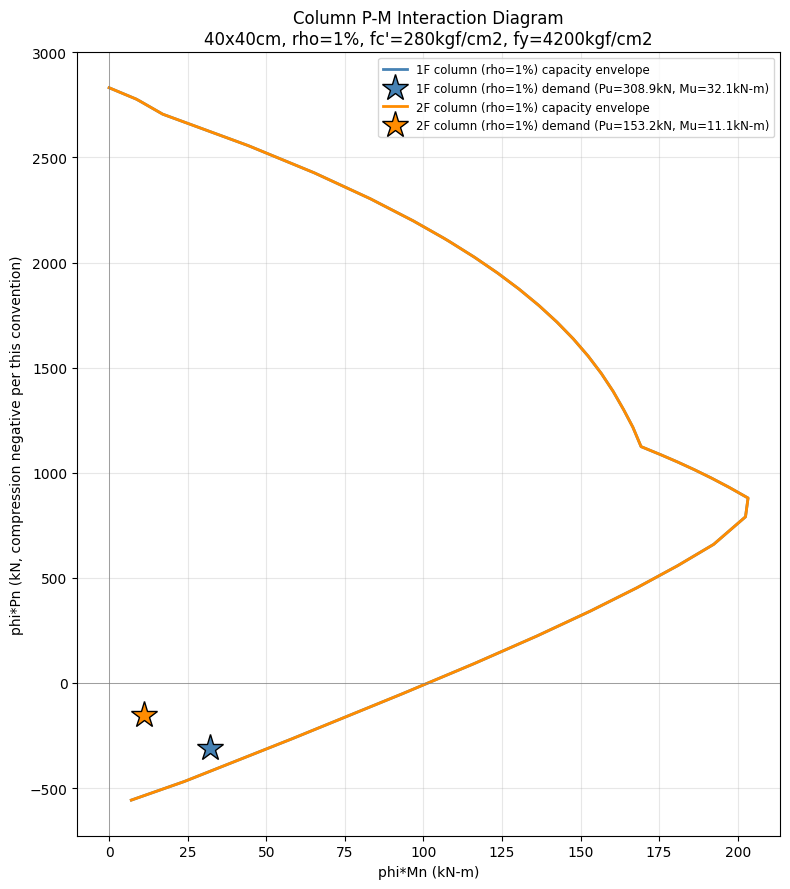

In [2]:

fig, ax = plt.subplots(figsize=(8, 9))

for r, label, color, Pu, Mu in [
    (r_col_1F, '1F column (rho=1%)', 'steelblue', Pu_1F, Mu_1F),
    (r_col_2F, '2F column (rho=1%)', 'darkorange', Pu_2F, Mu_2F),
]:
    curve = sorted(r['curve'], key=lambda p: p['Pn'])
    phiMn_list = [p['phiMn'] for p in curve]
    phiPn_list = [p['phiPn'] for p in curve]
    ax.plot(phiMn_list, phiPn_list, '-', color=color, lw=2, label=f'{label} capacity envelope')
    ax.plot(Mu, -Pu, '*', color=color, ms=20, mec='black', mew=1,
            label=f'{label} demand (Pu={Pu:.1f}kN, Mu={Mu:.1f}kN-m)')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('phi*Mn (kN-m)')
ax.set_ylabel('phi*Pn (kN, compression negative per this convention)')
ax.set_title('Column P-M Interaction Diagram\n40x40cm, rho=1%, fc\'=280kgf/cm2, fy=4200kgf/cm2')
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 圖 2:柱斷面配筋圖

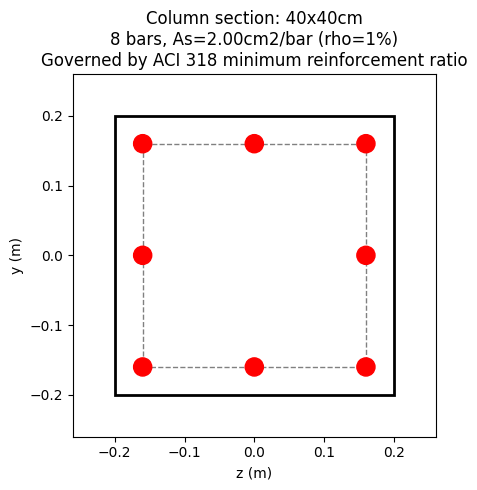

In [3]:

fig, ax = plt.subplots(figsize=(5, 5))
half = h_col/200; core_half = (h_col-2*4.0)/200
ax.add_patch(plt.Rectangle((-half,-half), h_col/100, h_col/100, fill=False, edgecolor='black', lw=2))
ax.add_patch(plt.Rectangle((-core_half,-core_half), 2*core_half, 2*core_half, fill=False, edgecolor='gray', lw=1, ls='--'))
bar_pos = [(-core_half,-core_half),(core_half,-core_half),(core_half,core_half),(-core_half,core_half),
           (0,-core_half),(0,core_half),(-core_half,0),(core_half,0)]
for (y,z) in bar_pos:
    ax.add_patch(plt.Circle((z,y), 0.013, color='red', zorder=5))
ax.set_xlim(-half-0.06, half+0.06); ax.set_ylim(-half-0.06, half+0.06)
ax.set_aspect('equal')
ax.set_title(f'Column section: 40x40cm\n8 bars, As={As_bar_col:.2f}cm2/bar (rho=1%)\nGoverned by ACI 318 minimum reinforcement ratio')
ax.set_xlabel('z (m)'); ax.set_ylabel('y (m)')
plt.tight_layout()
plt.show()


## 圖 3:梁斷面配筋圖(上下緣正負彎矩配筋)

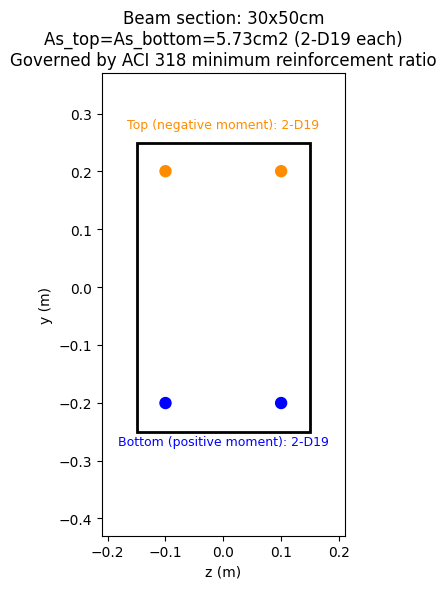

In [4]:

fig, ax = plt.subplots(figsize=(5, 6))
b_beam, h_beam = 30.0, 50.0
half_h, half_b = h_beam/200, b_beam/200
ax.add_patch(plt.Rectangle((-half_b,-half_h), b_beam/100, h_beam/100, fill=False, edgecolor='black', lw=2))
d_bar = 0.019
y_bot = -half_h + 0.04 + d_bar/2
y_top = half_h - 0.04 - d_bar/2
for x in [-half_b+0.05, half_b-0.05]:
    ax.add_patch(plt.Circle((x,y_bot), 0.0095, color='blue', zorder=5))
    ax.add_patch(plt.Circle((x,y_top), 0.0095, color='darkorange', zorder=5))
ax.annotate('Bottom (positive moment): 2-D19', (0, y_bot), fontsize=9, color='blue', xytext=(0,-30), textcoords='offset points', ha='center')
ax.annotate('Top (negative moment): 2-D19', (0, half_h+0.02), fontsize=9, color='darkorange', ha='center', va='bottom')
ax.set_xlim(-half_b-0.06, half_b+0.06); ax.set_ylim(-half_h-0.18, half_h+0.12)
ax.set_aspect('equal')
ax.set_title(f'Beam section: 30x50cm\nAs_top=As_bottom=5.73cm2 (2-D19 each)\nGoverned by ACI 318 minimum reinforcement ratio')
ax.set_xlabel('z (m)'); ax.set_ylabel('y (m)')
plt.tight_layout()
plt.show()


## 圖 4:柱端圍束區立面圖

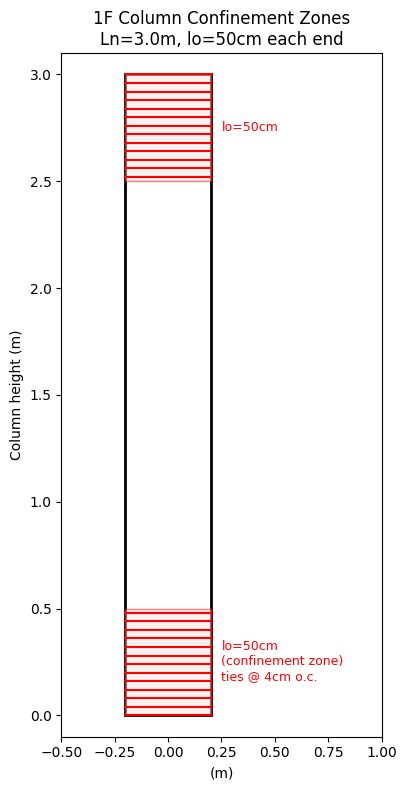

In [5]:

fig, ax = plt.subplots(figsize=(4, 8))
Ln_1F = (3.5-0.5)*100  # cm
lo = max(40.0, Ln_1F/6, 45.0)
s_conf = 4.0  # cm, 第6課算出的採用間距

col_width = 0.4
ax.add_patch(plt.Rectangle((-col_width/2, 0), col_width, Ln_1F/100, fill=False, edgecolor='black', lw=2))
# 圍束區(底部)
ax.add_patch(plt.Rectangle((-col_width/2, 0), col_width, lo/100, facecolor='mistyrose', edgecolor='red', lw=1, alpha=0.5))
# 圍束區(頂部)
ax.add_patch(plt.Rectangle((-col_width/2, Ln_1F/100-lo/100), col_width, lo/100, facecolor='mistyrose', edgecolor='red', lw=1, alpha=0.5))

n_ties_lo = int(lo/s_conf)
for k in range(n_ties_lo+1):
    y_tie = k*s_conf/100
    ax.plot([-col_width/2, col_width/2], [y_tie, y_tie], 'r-', lw=1.5)
    y_tie2 = Ln_1F/100 - k*s_conf/100
    ax.plot([-col_width/2, col_width/2], [y_tie2, y_tie2], 'r-', lw=1.5)

ax.annotate(f'lo={lo:.0f}cm\n(confinement zone)\nties @ {s_conf:.0f}cm o.c.',
            (col_width/2+0.05, lo/200), fontsize=9, color='red', va='center')
ax.annotate(f'lo={lo:.0f}cm', (col_width/2+0.05, Ln_1F/100-lo/200), fontsize=9, color='red', va='center')
ax.set_xlim(-0.5, 1.0); ax.set_ylim(-0.1, Ln_1F/100+0.1)
ax.set_aspect('equal')
ax.set_title(f'1F Column Confinement Zones\nLn={Ln_1F/100:.1f}m, lo={lo:.0f}cm each end')
ax.set_xlabel('(m)'); ax.set_ylabel('Column height (m)')
plt.tight_layout()
plt.show()


## 圖 5:規範檢核總覽長條圖(需求 `vs` 容量,標準化比值)

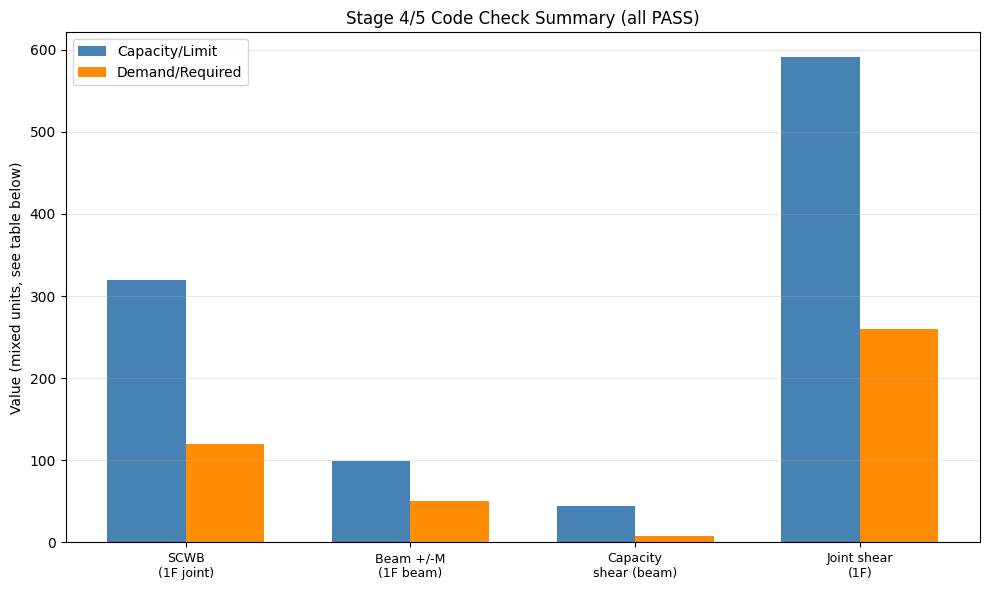

注意: 各檢核項目單位不同(kN-m, kN, cm), 這張圖只是視覺化
"容量 vs 需求"的相對關係, 不要直接跨項目比較長條高度


In [6]:

# 注意: "Column tie spacing"這一項的判定邏輯跟其他四項不同——
# 不是"capacity>demand才安全", 是"兩個間距限制取較小值當設計值",
# 混在同一張capacity-vs-demand長條圖裡容易誤導, 這裡故意排除,
# 另外用文字摘要表呈現
checks = [
    ('SCWB\n(1F joint)', 319.95, 119.27, 'sum(Mnc) vs 1.2*sum(Mnb)'),
    ('Beam +/-M\n(1F beam)', 99.39, 49.70, 'Mn+ vs 0.5*Mn-'),
    ('Capacity\nshear (beam)', 43.93, 8.06, 'Ve_hinge vs Vu_elastic\n(showing why elastic underestimates)'),
    ('Joint shear\n(1F)', 591.71, 259.87, 'phiVn vs Vj'),
]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(checks))
width = 0.35
capacities = [c[1] for c in checks]
demands = [c[2] for c in checks]
labels = [c[0] for c in checks]

ax.bar(x-width/2, capacities, width, label='Capacity/Limit', color='steelblue')
ax.bar(x+width/2, demands, width, label='Demand/Required', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Value (mixed units, see table below)')
ax.set_title('Stage 4/5 Code Check Summary (all PASS)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("注意: 各檢核項目單位不同(kN-m, kN, cm), 這張圖只是視覺化")
print("\"容量 vs 需求\"的相對關係, 不要直接跨項目比較長條高度")


## 完整文字摘要表——供不同工具獨立驗證

不看圖、不看程式碼,單靠這張表就能重新驗證每一項檢核。

In [7]:

summary = [
    dict(item='柱P-M互制(1F)', demand='Pu=308.85kN, Mu=32.13kN-m',
         capacity='phiPn/phiMn envelope(rho=1%, 40x40cm)', ratio='utilization=0.21', status='PASS', ref='ACI 318 22.4'),
    dict(item='柱P-M互制(2F)', demand='Pu=153.19kN, Mu=11.06kN-m',
         capacity='phiPn/phiMn envelope(rho=1%, 40x40cm)', ratio='utilization~0.08', status='PASS', ref='ACI 318 22.4'),
    dict(item='柱最小鋼筋比', demand='strength-required rho=0.4~1.0%',
         capacity='code minimum rho=1.0%', ratio='governed by code min', status='PASS', ref='ACI 318 10.6.1.1'),
    dict(item='梁最小鋼筋比', demand='rho_req=0.00115',
         capacity='rho_min=0.00333', ratio='governed by code min', status='PASS', ref='ACI 318 9.6.1.2'),
    dict(item='強柱弱梁(1F接頭)', demand='1.2*sum(Mnb)=119.27kN-m',
         capacity='sum(Mnc)=319.95kN-m', ratio='3.22', status='PASS', ref='ACI 318 18.7.3.2'),
    dict(item='梁正負彎矩(1F)', demand='0.5*Mn-=49.70kN-m',
         capacity='Mn+=99.39kN-m', ratio='1.00', status='PASS', ref='ACI 318 18.6.3.1'),
    dict(item='梁capacity-design shear', demand='Vu_elastic=8.06kN(供對照)',
         capacity='Ve_hinge=43.93kN(採用值)', ratio='5.45x elastic', status='採用Ve_hinge', ref='ACI 318 18.6.5.1'),
    dict(item='柱端圍束(1F)', demand='lo=50cm, s_req=4.0cm',
         capacity='s_max=9.6cm(排列限制)', ratio='governed by Ash/s', status='PASS', ref='ACI 318 18.7.5'),
    dict(item='梁柱接頭剪力(1F)', demand='Vj=259.87kN',
         capacity='phiVn=591.71kN', ratio='2.28', status='PASS', ref='ACI 318 18.8.4'),
]

print(f"{'項目':<18}{'需求':<28}{'容量':<28}{'比值':<16}{'狀態':<10}{'規範依據'}")
print('-'*130)
for s in summary:
    print(f"{s['item']:<18}{s['demand']:<28}{s['capacity']:<28}{s['ratio']:<16}{s['status']:<10}{s['ref']}")


項目                需求                          容量                          比值              狀態        規範依據
----------------------------------------------------------------------------------------------------------------------------------
柱P-M互制(1F)        Pu=308.85kN, Mu=32.13kN-m   phiPn/phiMn envelope(rho=1%, 40x40cm)utilization=0.21PASS      ACI 318 22.4
柱P-M互制(2F)        Pu=153.19kN, Mu=11.06kN-m   phiPn/phiMn envelope(rho=1%, 40x40cm)utilization~0.08PASS      ACI 318 22.4
柱最小鋼筋比            strength-required rho=0.4~1.0%code minimum rho=1.0%       governed by code minPASS      ACI 318 10.6.1.1
梁最小鋼筋比            rho_req=0.00115             rho_min=0.00333             governed by code minPASS      ACI 318 9.6.1.2
強柱弱梁(1F接頭)        1.2*sum(Mnb)=119.27kN-m     sum(Mnc)=319.95kN-m         3.22            PASS      ACI 318 18.7.3.2
梁正負彎矩(1F)         0.5*Mn-=49.70kN-m           Mn+=99.39kN-m               1.00            PASS      ACI 318 18.6.3.1
梁capacity-design shearVu_elastic=8.06kN(供對照

## 小結

這份視覺化摘要把 `stage4_5_rc_design_scwb.ipynb` 的全部 `5` 項規範
檢核轉成圖表跟文字摘要表——`P-M` 互制圖是最重要的一張,直接看出
需求點落在容量包絡線內。文字摘要表可以單獨列印或截圖,交給任何
使用不同工具的人獨立驗算,不需要重跑這份 `notebook`。